# MERFISH S2R3 to S2R2

This report reproduces the uncertainty analysis described for the
MERFISH mouse-brain benchmark in the paper. The query is Vizgen section **S2R3**
(85,958 cells) and the reference is section **S2R2** (84,172 cells).

Ten independent replicates retain 80% of the cells from each original section.
The complete cross-sample workflow was re-estimated for every replicate, so the
variation propagated through structure construction, pre-alignment,
rasterization, and S-LDDMM. The analysis measures the stability of those learned
transformations; it is not a calibrated probability or confidence interval.

Data source: [Vizgen Mouse Brain Receptor Map](https://info.vizgen.com/mouse-brain-map).

**Fixed-seed reproducibility.** This workflow uses seed `1000`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## 1. Experimental design

For each replicate, cells were sampled independently without replacement using
fixed replicate- and sample-specific seeds. The upstream workflow comprised:

1. per-sample BANKSY representation learning;
2. PCA, Harmony integration, and SNN Leiden clustering at resolution 1.4;
3. boundary-aware spatial-structure refinement;
4. weighted shared-centroid Procrustes pre-alignment with scaling and no reflection;
5. multichannel structure-composition and density pseudo-images; and
6. S-LDDMM registration.

The prepared `.npz` files used below are the outputs of steps 1–5 for each
independent replicate. This report runs or loads step 6, applies all ten saved
transformations to a common evaluation support, and regenerates the pointwise
variability figures and tables.

### Adapting the subsampling design

The ten 80% replicates are an experimental design choice, not an S-LDDMM
default. For another dataset, choose the retained fraction high enough to
preserve all important spatial structures and use enough independent repeats
to stabilize the tail of the variability distribution. Re-run clustering,
pre-alignment, rasterization and S-LDDMM independently for every replicate.

Evaluate every learned transformation on one fixed support; otherwise changing
cell membership is confounded with transformation variability. Report the
number of repeats, retained fraction, random seeds and all alignment parameters.
The resulting spread is empirical subsampling stability, not a posterior
probability or confidence interval.

## 2. Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

from spAlignDE import uncertainty as uq

PROJECT_ROOT = Path.cwd().resolve()
INPUT_DIR = Path(
    os.environ.get(
        "SPALIGNDE_UNCERTAINTY_INPUT_DIR",
        PROJECT_ROOT / "data" / "cross_sample" / "mouse_brain" / "uncertainty" / "lddmm_inputs",
    )
)
OUTPUT_DIR = Path(
    os.environ.get(
        "SPALIGNDE_UNCERTAINTY_OUTPUT_DIR",
        PROJECT_ROOT / "outputs" / "cross_sample_uncertainty",
    )
)
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

uq.set_plot_style()

if not INPUT_DIR.exists():
    raise FileNotFoundError(
        f"Prepared replicate inputs were not found at {INPUT_DIR}. "
        "Place lddmm_input_rep01.npz through lddmm_input_rep10.npz there, "
        "or set SPALIGNDE_UNCERTAINTY_INPUT_DIR."
    )

print("Input set: 10 prepared LDDMM replicates")
print("Output directory:", OUTPUT_DIR.name)

Input set: 10 prepared LDDMM replicates
Output directory: cross_sample_uncertainty


## 3. Validate the ten 80% replicates

The source count is 68,766 in every replicate (80% of 85,958, rounded down),
and the reference count is 67,337 (80% of 84,172, rounded down).

In [2]:
manifest = uq.discover_lddmm_inputs(INPUT_DIR)
assert [item["repeat"] for item in manifest] == list(range(1, 11))

replicate_rows = []
for item in manifest:
    dat = uq.load_repeat_input(item["path"])
    replicate_rows.append(
        {
            "replicate": item["repeat"],
            "query_cells": len(dat["x_src_prealign"]),
            "reference_cells": len(dat["x_tgt"]),
            "prealignment": str(np.asarray(dat.get("prealign_method", "unknown")).item()),
        }
    )

replicate_table = pd.DataFrame(replicate_rows)
assert len(replicate_table) == 10
assert set(replicate_table["query_cells"]) == {68_766}
assert set(replicate_table["reference_cells"]) == {67_337}
display(replicate_table)

,replicate,query_cells,reference_cells,prealignment
0,1,68766,67337,shared_cluster_weighted_procrustes
1,2,68766,67337,shared_cluster_weighted_procrustes
2,3,68766,67337,shared_cluster_weighted_procrustes
3,4,68766,67337,shared_cluster_weighted_procrustes
4,5,68766,67337,shared_cluster_weighted_procrustes
5,6,68766,67337,shared_cluster_weighted_procrustes
6,7,68766,67337,shared_cluster_weighted_procrustes
7,8,68766,67337,shared_cluster_weighted_procrustes
8,9,68766,67337,shared_cluster_weighted_procrustes
9,10,68766,67337,shared_cluster_weighted_procrustes


## 4. Run or load the replicate S-LDDMM transformations

`FORCE_RERUN=False` uses the transformations already generated with the paper's
parameters. Set it to `True` to re-estimate all ten transformations. The output
directory is controlled by ``SPALIGNDE_UNCERTAINTY_OUTPUT_DIR`` and defaults to
``outputs/cross_sample_uncertainty`` under the notebook working directory.

In [3]:
FORCE_RERUN = os.environ.get("SPALIGNDE_FORCE_UNCERTAINTY_RERUN", "0") == "1"

model_cfg = {
    "a": 300,
    "p": 2.0,
    "expand": 2.0,
    "nt": 3,
    "grid_step": 100,
}
optim_cfg = {
    "niter": 500,
    "diffeo_start": 0,
    "lrL": 2e-8,
    "lrT": 2e-1,
    "lrM": 2e3,
    "affine_slowdown": 10.0,
    "grad_clip_m0": None,
    "lrM_decay": 1.0,
    "lrM_min": 2e3,
}

aligned_by_repeat, run_summary = uq.run_or_load_alignments(
    manifest,
    output_dir=OUTPUT_DIR,
    model_cfg=model_cfg,
    optim_cfg=optim_cfg,
    force=FORCE_RERUN,
    save_transforms=True,
    require_transforms=True,
    verbose=False,
)
display(
    run_summary[
        ["repeat", "status", "n_source_points", "n_target_points", "prealign_method", "finalE", "elapsed_sec"]
    ]
)


=== Running LDDMM repeat 01 ===



=== Running LDDMM repeat 02 ===



=== Running LDDMM repeat 03 ===



=== Running LDDMM repeat 04 ===



=== Running LDDMM repeat 05 ===


...


=== Running LDDMM repeat 07 ===



=== Running LDDMM repeat 08 ===



=== Running LDDMM repeat 09 ===



=== Running LDDMM repeat 10 ===


,repeat,status,n_source_points,n_target_points,prealign_method,finalE,elapsed_sec
0,1,ran,68766,67337,shared_cluster_weighted_procrustes,8576.507463,19.810865
1,2,ran,68766,67337,shared_cluster_weighted_procrustes,8147.642341,32.967245
2,3,ran,68766,67337,shared_cluster_weighted_procrustes,9315.090842,18.930076
3,4,ran,68766,67337,shared_cluster_weighted_procrustes,8190.309770,19.571571
4,5,ran,68766,67337,shared_cluster_weighted_procrustes,8412.782143,33.540792
5,6,ran,68766,67337,shared_cluster_weighted_procrustes,8477.063799,19.417594
6,7,ran,68766,67337,shared_cluster_weighted_procrustes,8424.620902,32.787966
7,8,ran,68766,67337,shared_cluster_weighted_procrustes,8592.896435,33.087242
8,9,ran,68766,67337,shared_cluster_weighted_procrustes,8424.799445,19.501006
9,10,ran,68766,67337,shared_cluster_weighted_procrustes,8555.501515,33.305157


## 5. Replicate-level alignment quality control

These panels overlay each independently subsampled query result on its
replicate-specific reference subset. They verify that no single replicate
failed before pointwise variability is summarized.

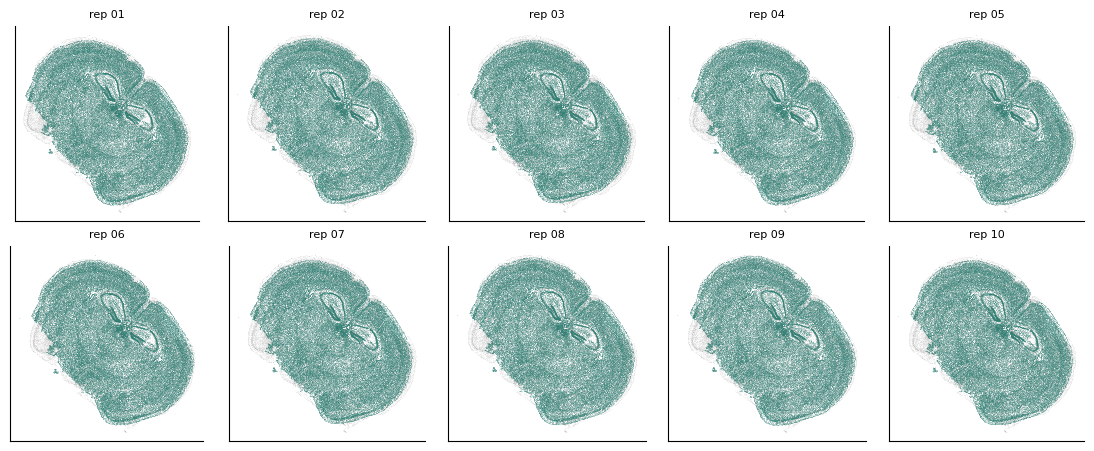

In [4]:
target_xy = uq.load_target_xy(manifest[0]["path"])
fig = uq.plot_all_replicate_overlays(aligned_by_repeat, target_xy, ncols=5)
fig.savefig(FIG_DIR / "ten_replicate_alignment_qc.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "ten_replicate_alignment_qc.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Evaluate every transformation on the same query points

Directly comparing each replicate's output cells would mix transformation
variability with changing subsample membership. We therefore use the
replicate-1 prealigned query points as a fixed support. For fixed point
(p_i), transformation (T_r) yields

\[
z_{r,i}=T_r(p_i), \qquad
\bar z_i=\frac{1}{R}\sum_{r=1}^{R}z_{r,i}, \qquad
d_{r,i}=\lVert z_{r,i}-\bar z_i\rVert_2.
\]

The coordinate spread is

\[
s_i=\sqrt{s_{x,i}^2+s_{y,i}^2},
\]

and the primary metric displayed in Figure 2E is the sample variance of
distance from the repeat mean,

\[
v_{d,i}=\frac{1}{R-1}\sum_{r=1}^{R}(d_{r,i}-\bar d_i)^2.
\]

In the output table, $s_i$ is `std_total` and $v_{d,i}$ is `dist_var`.

In [5]:
reference_input = manifest[0]["path"]
transforms_by_repeat = uq.load_saved_transforms(OUTPUT_DIR / "transforms")
assert sorted(transforms_by_repeat) == list(range(1, 11))

mapped_fixed_query, x_fixed, y_fixed = uq.map_reference_points_through_transforms(
    transforms_by_repeat,
    reference_input_path=reference_input,
)
point_var_df, distance_to_mean = uq.compute_repeat_point_variance(
    mapped_fixed_query,
    x_fixed,
    y_fixed,
)
assert len(point_var_df) == 68_766
assert distance_to_mean.shape == (10, 68_766)

table_path = OUTPUT_DIR / "pointwise_transformation_variability.csv"
point_var_df.to_csv(table_path, index=False)
display(point_var_df.head())

,point_idx,x_src,y_src,x_mean,y_mean,var_x,var_y,dist_mean,dist_var,dist_std,var_total,std_x,std_y,std_total
0,0,1180.233643,7988.023438,1178.288916,7978.991699,141.253786,148.176735,15.336742,28.079792,5.299037,289.430521,11.885024,12.172787,17.012658
1,1,1240.368408,8066.828613,1235.498083,8061.067139,122.446013,177.581568,15.527952,32.119494,5.667406,300.027581,11.065533,13.325973,17.321304
2,2,1217.747070,8071.111328,1213.459521,8064.864111,122.750587,171.382151,15.382308,31.226743,5.588089,294.132738,11.079286,13.091301,17.150298
3,3,1227.177734,8087.344238,1222.380457,8081.688867,119.409553,176.721617,15.414169,32.134939,5.668769,296.131170,10.927468,13.293668,17.208462
4,4,1189.961548,8008.821777,1187.417017,8000.498291,136.376297,153.858131,15.342655,28.682146,5.355572,290.234428,11.678026,12.403956,17.036268


## 7. Spatial map of transformation variability

Replicate-1 aligned query points are colored by `dist_var`. The dashed contour
summarizes points at or above the 95th percentile, matching the paper's
high-variability-region definition. The color scale is capped at the 99th
percentile so a few extremes do not suppress spatial contrast.

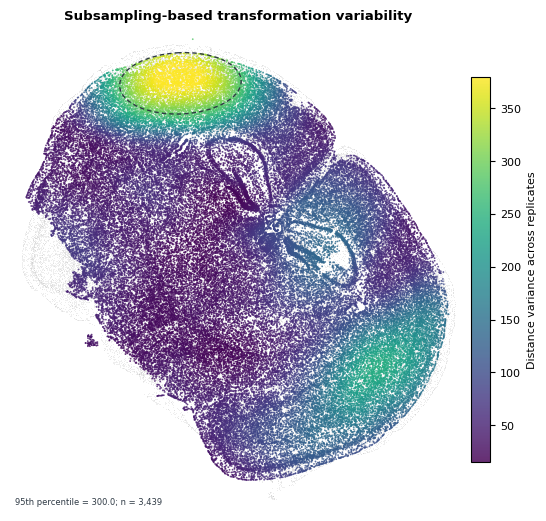

In [6]:
fig = uq.plot_distance_variance_map(
    point_var_df,
    mapped_fixed_query,
    target_xy,
    repeat=1,
    high_percentile=95.0,
    vmax_percentile=99.0,
)
fig.savefig(FIG_DIR / "merfish_S2R3_to_S2R2_distance_variance.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "merfish_S2R3_to_S2R2_distance_variance.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Distribution and numerical summary

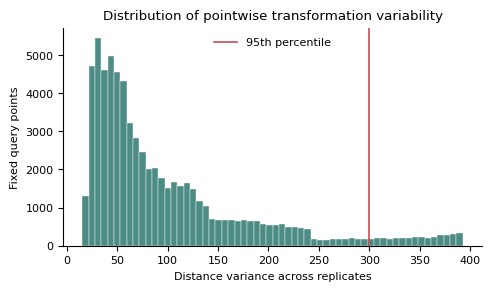

,metric,median,95th percentile
0,dist_var,68.43,300.01
1,std_total,18.09,36.62
2,dist_mean,14.52,30.61
3,dist_std,8.27,17.32


High-variability fixed query points: 3,439 / 68,766
Saved pointwise table, figures, and uncertainty_report.json.


In [7]:
fig, p95_dist_var = uq.plot_uncertainty_distribution(
    point_var_df,
    value_col="dist_var",
    high_percentile=95.0,
)
fig.savefig(FIG_DIR / "merfish_S2R3_to_S2R2_dist_var_distribution.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "merfish_S2R3_to_S2R2_dist_var_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

summary_table = pd.DataFrame(
    {
        "metric": ["dist_var", "std_total", "dist_mean", "dist_std"],
        "median": [point_var_df[c].median() for c in ["dist_var", "std_total", "dist_mean", "dist_std"]],
        "95th percentile": [
            point_var_df[c].quantile(0.95) for c in ["dist_var", "std_total", "dist_mean", "dist_std"]
        ],
    }
)
display(summary_table.round(2))

report_path = uq.write_brief_report(
    output_dir=OUTPUT_DIR,
    summary=run_summary,
    uncertainty_df=point_var_df,
    high_percentile=95.0,
)
print(f"High-variability fixed query points: {(point_var_df['dist_var'] >= p95_dist_var).sum():,} / {len(point_var_df):,}")
print("Saved pointwise table, figures, and uncertainty_report.json.")

## 9. Interpretation

Most of the section has low pointwise distance variance, showing that the
estimated correspondence is stable to cell subsampling. Elevated variability
is spatially concentrated near the weakly or incompletely overlapping tissue
boundary, where the transformation has less shared anatomical support.

This result should be read as **empirical subsampling-based transformation
stability**. It flags locations where downstream comparisons deserve caution;
it does not estimate a posterior probability, a confidence interval, or error
relative to a known ground-truth deformation.